# K-Nearest Neighbors (KNN) Explained
### Perfect for YouTube Shorts!

**What is KNN?**
- Classification algorithm that predicts based on nearest neighbors
- 'K' = number of neighbors to consider
- Simple yet powerful!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")

## 1. Create Sample Data
Two classes of data points

In [2]:
# Generate simple 2D dataset
np.random.seed(42)
X, y = make_classification(n_samples=50, n_features=2, n_redundant=0, 
                          n_informative=2, n_clusters_per_class=1,
                          flip_y=0.1, class_sep=1.5)

# Split into two classes
X_class0 = X[y == 0]
X_class1 = X[y == 1]

print(f"Class 0: {len(X_class0)} points")
print(f"Class 1: {len(X_class1)} points")

Class 0: 24 points
Class 1: 26 points


## 2. Visualize the Data

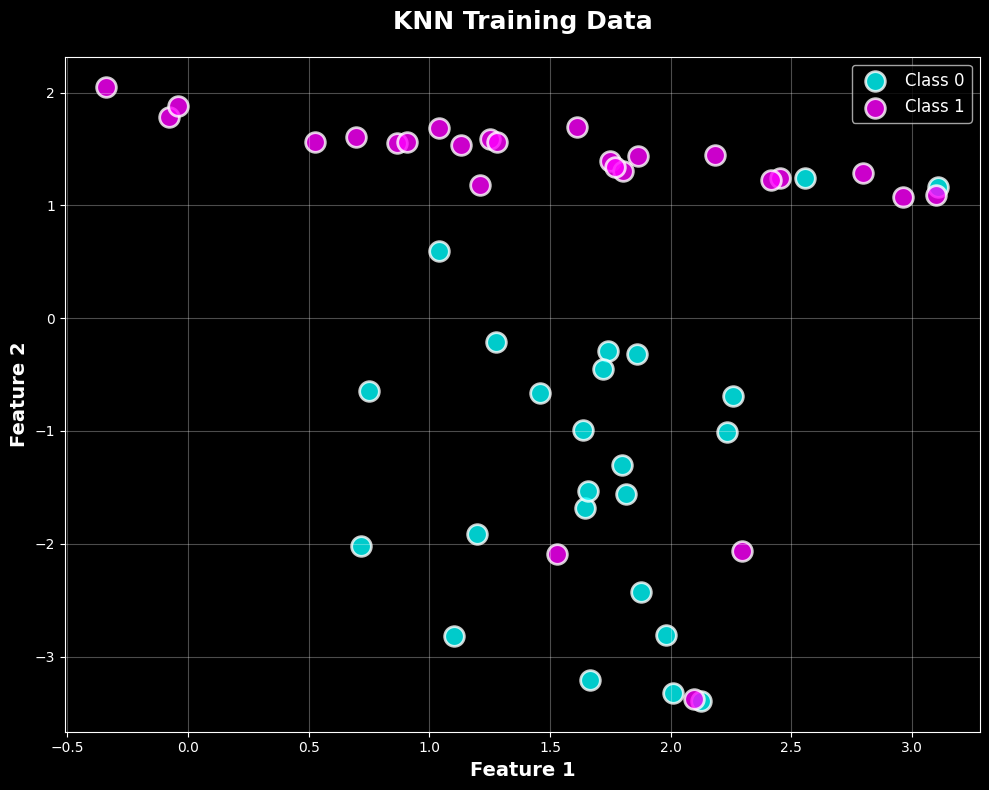

In [3]:
plt.figure(figsize=(10, 8))
plt.scatter(X_class0[:, 0], X_class0[:, 1], c='cyan', s=200, 
           edgecolors='white', linewidth=2, label='Class 0', alpha=0.8)
plt.scatter(X_class1[:, 0], X_class1[:, 1], c='magenta', s=200, 
           edgecolors='white', linewidth=2, label='Class 1', alpha=0.8)
plt.xlabel('Feature 1', fontsize=14, fontweight='bold')
plt.ylabel('Feature 2', fontsize=14, fontweight='bold')
plt.title('KNN Training Data', fontsize=18, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. How KNN Works: Step by Step

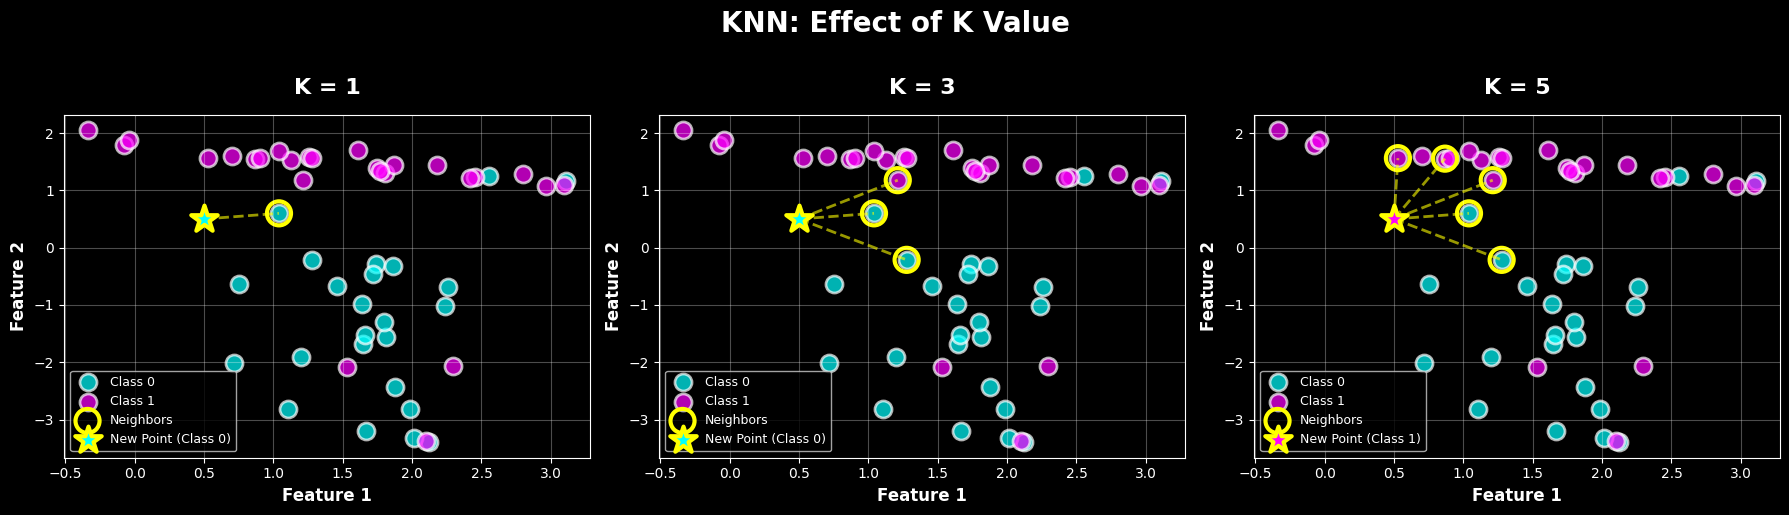

In [4]:
# New point to classify
new_point = np.array([[0.5, 0.5]])

# Try different K values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values = [1, 3, 5]

for idx, k in enumerate(k_values):
    ax = axes[idx]
    
    # Plot existing data
    ax.scatter(X_class0[:, 0], X_class0[:, 1], c='cyan', s=150, 
              edgecolors='white', linewidth=2, label='Class 0', alpha=0.7)
    ax.scatter(X_class1[:, 0], X_class1[:, 1], c='magenta', s=150, 
              edgecolors='white', linewidth=2, label='Class 1', alpha=0.7)
    
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    
    # Find K nearest neighbors
    distances, indices = knn.kneighbors(new_point)
    
    # Draw lines to neighbors
    for neighbor_idx in indices[0]:
        ax.plot([new_point[0, 0], X[neighbor_idx, 0]], 
               [new_point[0, 1], X[neighbor_idx, 1]], 
               'yellow', linewidth=2, alpha=0.6, linestyle='--')
    
    # Highlight neighbors
    neighbors = X[indices[0]]
    ax.scatter(neighbors[:, 0], neighbors[:, 1], 
              facecolors='none', edgecolors='yellow', 
              s=300, linewidth=3, label='Neighbors')
    
    # Plot new point
    prediction = knn.predict(new_point)[0]
    color = 'cyan' if prediction == 0 else 'magenta'
    ax.scatter(new_point[:, 0], new_point[:, 1], c=color, s=400, 
              marker='*', edgecolors='yellow', linewidth=3, 
              label=f'New Point (Class {prediction})', zorder=5)
    
    ax.set_title(f'K = {k}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('KNN: Effect of K Value', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Decision Boundaries
See how KNN divides the space

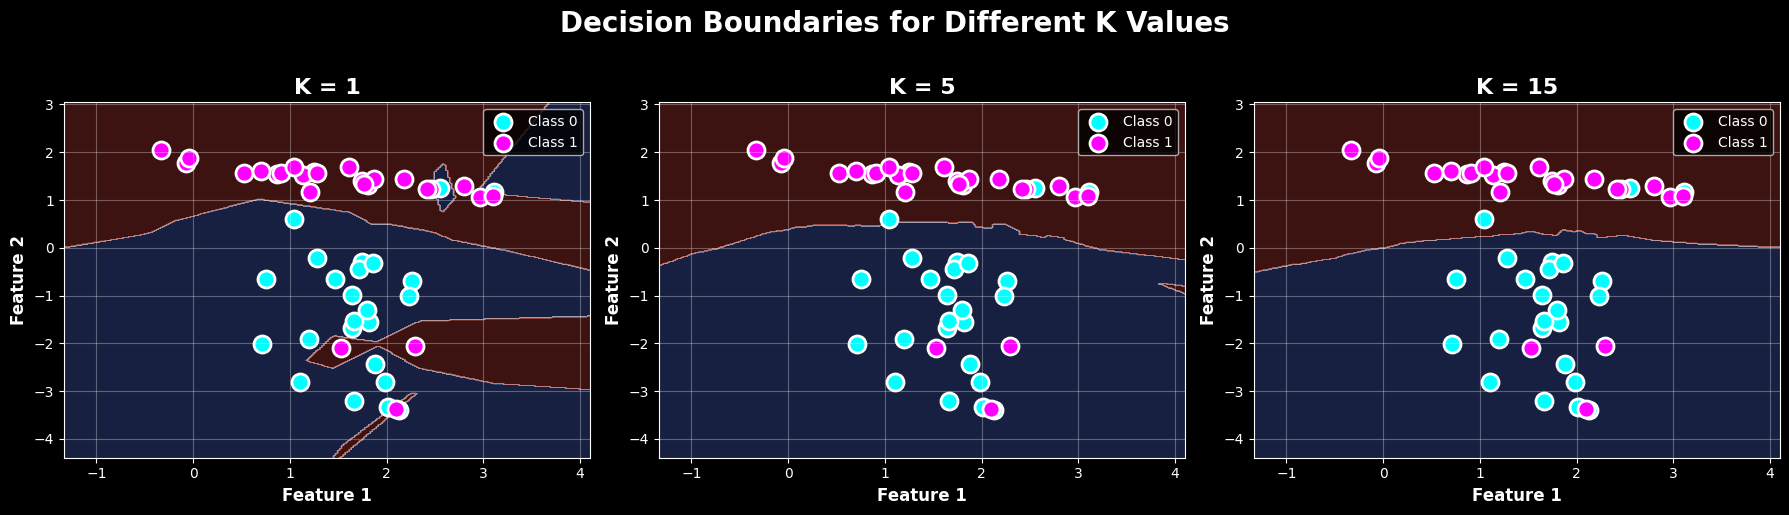

In [5]:
def plot_decision_boundary(k, ax):
    # Train model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    
    # Create mesh
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # Plot data points
    ax.scatter(X_class0[:, 0], X_class0[:, 1], c='cyan', s=150, 
              edgecolors='white', linewidth=2, label='Class 0')
    ax.scatter(X_class1[:, 0], X_class1[:, 1], c='magenta', s=150, 
              edgecolors='white', linewidth=2, label='Class 1')
    
    ax.set_title(f'K = {k}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

# Plot for different K values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, k in enumerate([1, 5, 15]):
    plot_decision_boundary(k, axes[idx])

plt.suptitle('Decision Boundaries for Different K Values', 
            fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Key Takeaways

**Low K (e.g., K=1):**
- More complex boundaries
- Can overfit to noise
- Sensitive to outliers

**High K (e.g., K=15):**
- Smoother boundaries
- More generalized
- Can underfit

**Sweet Spot (e.g., K=3-5):**
- Balance between complexity and generalization
- Often works well in practice

## 6. Interactive Prediction

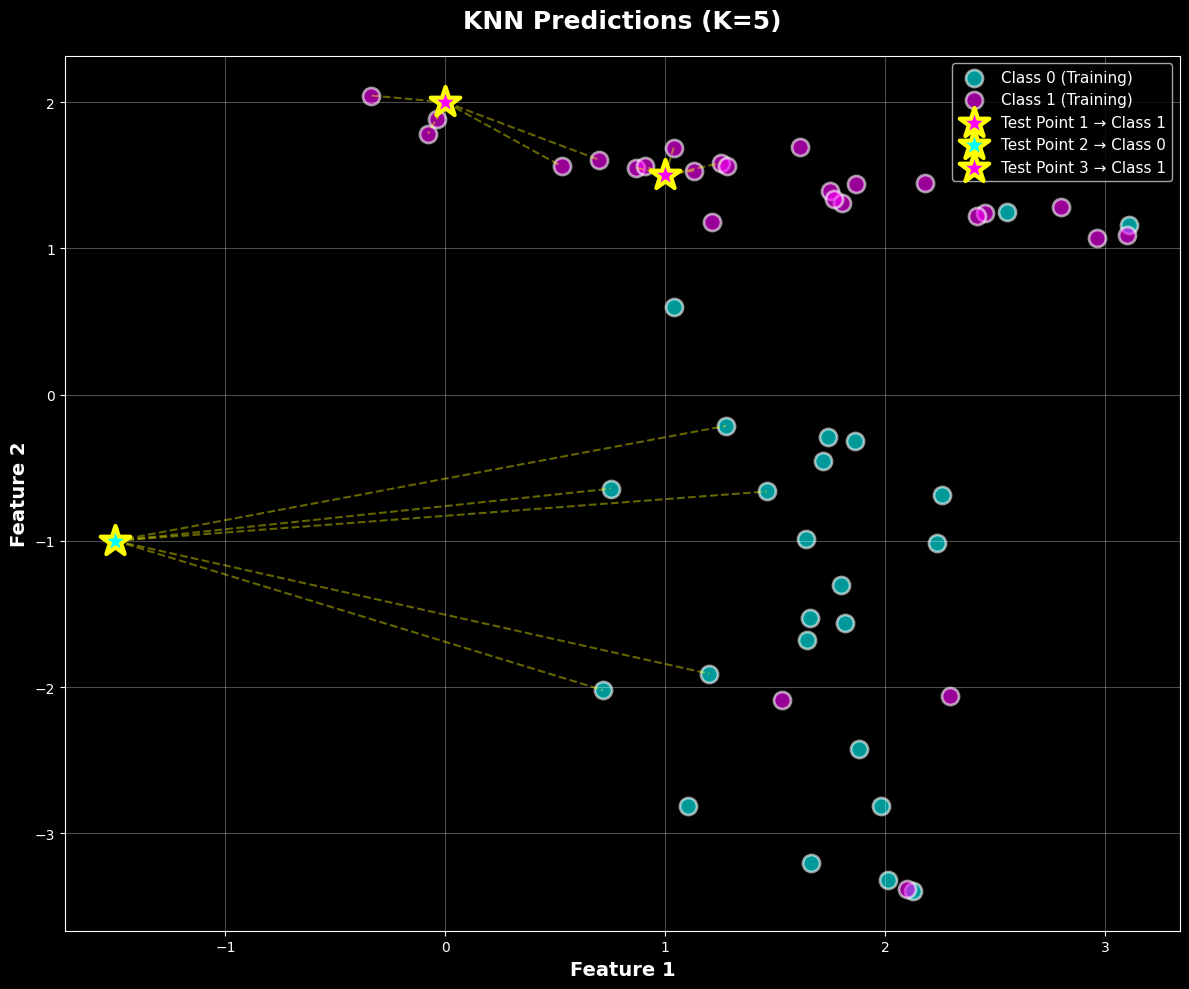


Predictions:
Test Point 1 [1.  1.5] → Class 1
Test Point 2 [-1.5 -1. ] → Class 0
Test Point 3 [0. 2.] → Class 1


In [6]:
# Make predictions on multiple new points
test_points = np.array([[1.0, 1.5], [-1.5, -1.0], [0.0, 2.0]])
k = 5

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X, y)
predictions = knn.predict(test_points)

plt.figure(figsize=(12, 10))

# Plot training data
plt.scatter(X_class0[:, 0], X_class0[:, 1], c='cyan', s=150, 
           edgecolors='white', linewidth=2, label='Class 0 (Training)', alpha=0.6)
plt.scatter(X_class1[:, 0], X_class1[:, 1], c='magenta', s=150, 
           edgecolors='white', linewidth=2, label='Class 1 (Training)', alpha=0.6)

# Plot predictions
for i, (point, pred) in enumerate(zip(test_points, predictions)):
    color = 'cyan' if pred == 0 else 'magenta'
    plt.scatter(point[0], point[1], c=color, s=500, marker='*', 
               edgecolors='yellow', linewidth=3, 
               label=f'Test Point {i+1} → Class {pred}', zorder=5)
    
    # Find and draw neighbors
    distances, indices = knn.kneighbors([point])
    for neighbor_idx in indices[0]:
        plt.plot([point[0], X[neighbor_idx, 0]], 
                [point[1], X[neighbor_idx, 1]], 
                'yellow', linewidth=1.5, alpha=0.4, linestyle='--')

plt.xlabel('Feature 1', fontsize=14, fontweight='bold')
plt.ylabel('Feature 2', fontsize=14, fontweight='bold')
plt.title(f'KNN Predictions (K={k})', fontsize=18, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPredictions:")
for i, (point, pred) in enumerate(zip(test_points, predictions)):
    print(f"Test Point {i+1} {point} → Class {pred}")